# Exemplos Computacionais - Capítulo 02: Modelagem Matemática

Este notebook contém todos os exemplos apresentados nos slides do Capítulo 02.


In [8]:
! pip install numpy
! pip install matplotlib
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 9.0 MB/s  0:00:03m0:00:0100:01m


## 1. Decaimento Radioativo


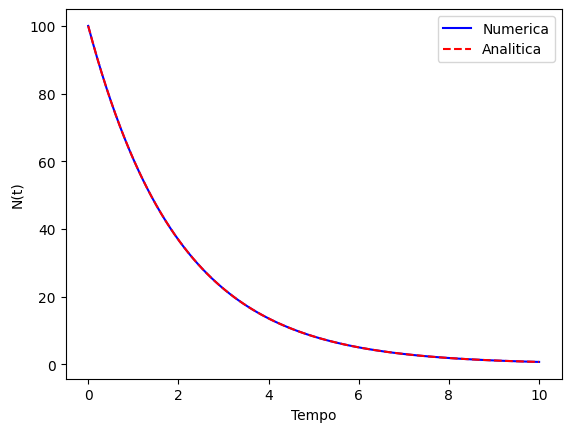

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Definir a EDO
def decay(N, t, lam):
    """Taxa de variacao de N"""
    return -lam * N

# Parametros
lambda_val = 0.5  # constante de decaimento
N0 = 100          # quantidade inicial
t = np.linspace(0, 10, 100)

# Resolver numericamente
N_num = odeint(decay, N0, t, args=(lambda_val,))

# Solucao analitica
N_ana = N0 * np.exp(-lambda_val * t)

# Plotar
plt.plot(t, N_num, 'b-', label='Numerica')
plt.plot(t, N_ana, 'r--', label='Analitica')
plt.xlabel('Tempo')
plt.ylabel('N(t)')
plt.legend()
plt.show()


## 2. Crescimento Logístico


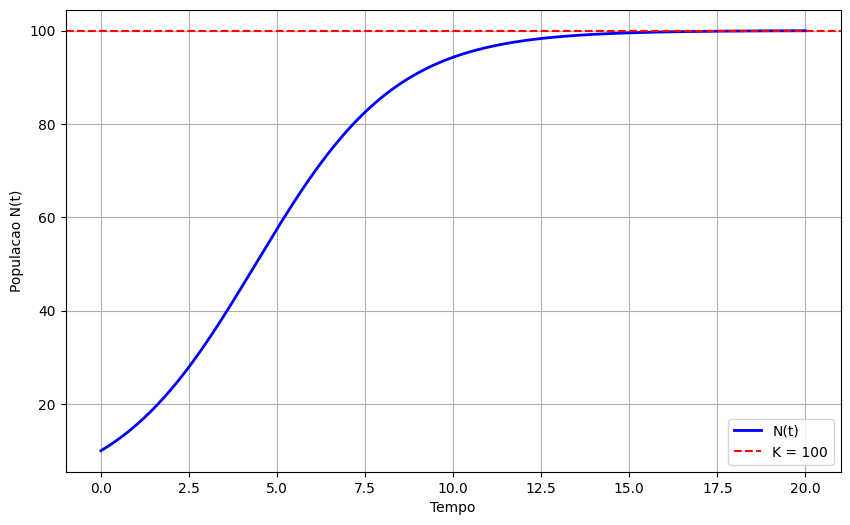

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def logistic(N, t, r, K):
    """Modelo de crescimento logistico"""
    return r * N * (1 - N/K)

# Parametros
r = 0.5    # taxa de crescimento
K = 100    # capacidade de suporte
N0 = 10    # populacao inicial

# Tempo
t = np.linspace(0, 20, 200)

# Resolver
N = odeint(logistic, N0, t, args=(r, K))

# Plotar
plt.figure(figsize=(10, 6))
plt.plot(t, N, 'b-', linewidth=2, label='N(t)')
plt.axhline(y=K, color='r', linestyle='--',
            label=f'K = {K}')
plt.xlabel('Tempo')
plt.ylabel('Populacao N(t)')
plt.legend()
plt.grid(True)
plt.show()


## 3. Modelo Predador-Presa (Lotka-Volterra)


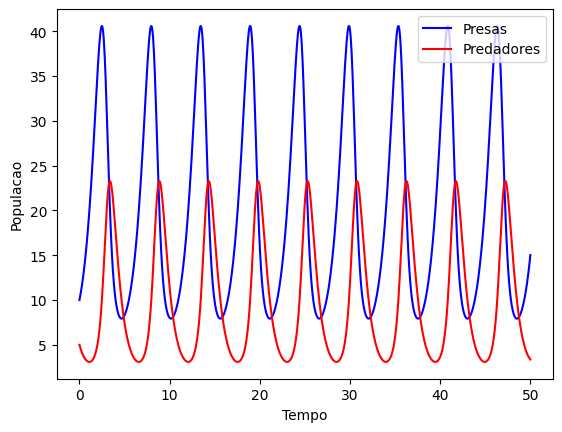

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def lotka_volterra(y, t, alpha, beta, delta, gamma):
    """Sistema Lotka-Volterra"""
    V, P = y
    dVdt = alpha*V - beta*V*P
    dPdt = delta*beta*V*P - gamma*P
    return [dVdt, dPdt]

# Parametros
alpha = 1.0
beta = 0.1
delta = 0.75
gamma = 1.5

# Condicoes iniciais
y0 = [10, 5]  # [V0, P0]
t = np.linspace(0, 50, 1000)

# Resolver
sol = odeint(lotka_volterra, y0, t, args=(alpha, beta, delta, gamma))

# Plotar series temporais
plt.plot(t, sol[:, 0], 'b-', label='Presas')
plt.plot(t, sol[:, 1], 'r-', label='Predadores')
plt.xlabel('Tempo')
plt.ylabel('Populacao')
plt.legend()
plt.show()


### Plano de Fase: Predador-Presa


In [ ]:
# Retrato de fase
plt.figure()
plt.plot(sol[:, 0], sol[:, 1], 'g-', linewidth=2)
plt.plot(sol[0, 0], sol[0, 1], 'go', markersize=10, label='Inicio')
plt.xlabel('Presas (V)')
plt.ylabel('Predadores (P)')
plt.title('Retrato de Fase')
plt.legend()
plt.grid(True)

# Campo vetorial
V = np.linspace(0, 20, 20)
P = np.linspace(0, 15, 20)
V_grid, P_grid = np.meshgrid(V, P)
dV, dP = lotka_volterra([V_grid, P_grid], 0, alpha, beta, delta, gamma)
plt.quiver(V_grid, P_grid, dV, dP, alpha=0.5)
plt.show()


## 4. Análise de Estabilidade Computacional


In [12]:
import numpy as np
from scipy.linalg import eig

def jacobian_lotka_volterra(y, alpha, beta, delta, gamma):
    """Calcula Jacobiano do sistema LV"""
    V, P = y
    J = np.array([
        [alpha - beta*P, -beta*V],
        [delta*beta*P, delta*beta*V - gamma]
    ])
    return J

# Ponto de equilibrio
V_eq = gamma / (delta * beta)
P_eq = alpha / beta

# Calcular Jacobiano no equilibrio
J = jacobian_lotka_volterra([V_eq, P_eq], alpha, beta, delta, gamma)

# Autovalores
eigenvalues, eigenvectors = eig(J)
print(f"Autovalores: {eigenvalues}")
print(f"Partes reais: {eigenvalues.real}")


Autovalores: [0.+1.22474487j 0.-1.22474487j]
Partes reais: [0. 0.]


## 5. Método de Euler


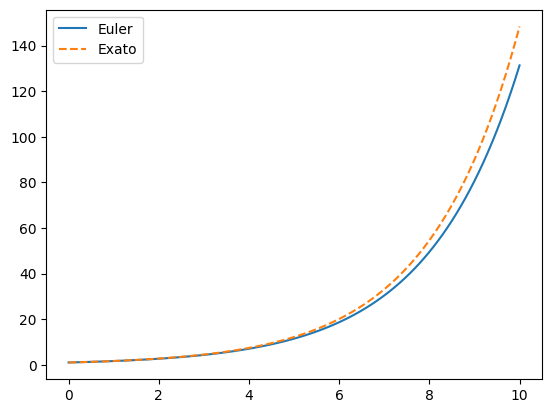

In [13]:
def euler(f, x0, t):
    """
    Metodo de Euler para resolver EDOs
    f: funcao dx/dt = f(x, t)
    x0: condicao inicial
    t: array de tempos
    """
    n = len(t)
    x = np.zeros((n, len(x0)))
    x[0] = x0

    for i in range(n-1):
        h = t[i+1] - t[i]
        x[i+1] = x[i] + h * np.array(f(x[i], t[i]))

    return x

# Exemplo: crescimento exponencial
def exp_growth(x, t, r=0.5):
    return r * x

t_euler = np.linspace(0, 10, 100)
x0_euler = [1.0]
x_euler = euler(lambda x,t: exp_growth(x,t), x0_euler, t_euler)

plt.plot(t_euler, x_euler, label='Euler')
plt.plot(t_euler, x0_euler[0]*np.exp(0.5*t_euler), '--', label='Exato')
plt.legend()
plt.show()


## 6. Método de Runge-Kutta 4 (RK4)


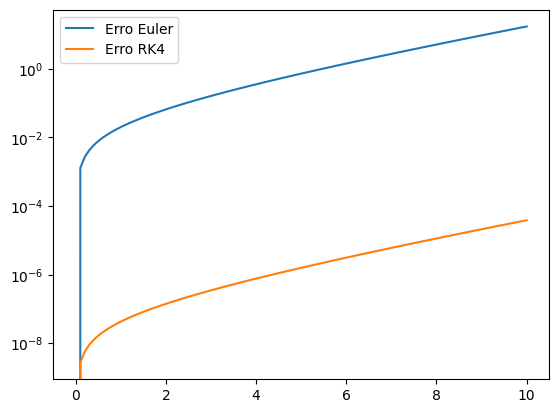

In [14]:
def rk4(f, x0, t):
    """Metodo Runge-Kutta de 4a ordem"""
    n = len(t)
    x = np.zeros((n, len(x0)))
    x[0] = x0

    for i in range(n-1):
        h = t[i+1] - t[i]
        k1 = np.array(f(x[i], t[i]))
        k2 = np.array(f(x[i] + h*k1/2, t[i] + h/2))
        k3 = np.array(f(x[i] + h*k2/2, t[i] + h/2))
        k4 = np.array(f(x[i] + h*k3, t[i] + h))

        x[i+1] = x[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

    return x

# Usar
x_rk4 = rk4(lambda x,t: exp_growth(x,t), x0_euler, t_euler)

# Comparar erro
erro_euler = np.abs(x_euler[:, 0] - x0_euler[0]*np.exp(0.5*t_euler))
erro_rk4 = np.abs(x_rk4[:, 0] - x0_euler[0]*np.exp(0.5*t_euler))
plt.plot(t_euler, erro_euler, label='Erro Euler')
plt.plot(t_euler, erro_rk4, label='Erro RK4')
plt.yscale('log')
plt.legend()
plt.show()


## 7. Análise de Sensibilidade Local


In [15]:
def sensitivity_local(model, params, param_names, perturbation=0.01):
    """Analise de sensibilidade local"""
    baseline = model(params)
    sensitivities = {}

    for i, name in enumerate(param_names):
        # Perturbar parametro
        params_pert = params.copy()
        params_pert[i] *= (1 + perturbation)

        # Calcular saida perturbada
        output_pert = model(params_pert)

        # Sensibilidade relativa
        S = (output_pert - baseline) / baseline / perturbation
        sensitivities[name] = S

    return sensitivities

# Exemplo
def logistic_final(params):
    r, K, N0 = params
    return K

sens = sensitivity_local(logistic_final, [0.5, 100, 10], ['r', 'K', 'N0'])
print("Sensibilidades relativas:", sens)


Sensibilidades relativas: {'r': 0.0, 'K': 1.0, 'N0': 0.0}


## 8. Ajuste de Curvas com scipy


r estimado: 0.480
K estimado: 102.889


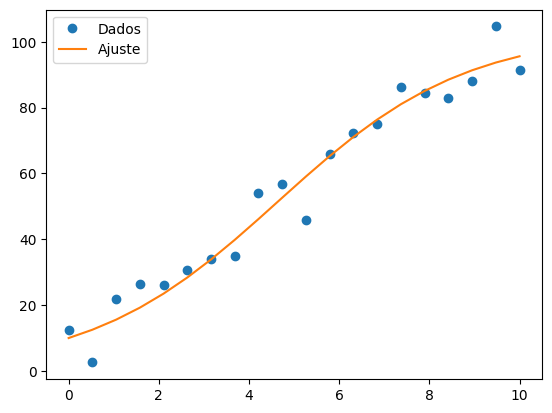

In [16]:
from scipy.optimize import curve_fit

# Dados experimentais (com ruido)
t_data = np.linspace(0, 10, 20)
r_true, K_true = 0.5, 100
N_true = K_true / (1 + (K_true/10 - 1)*np.exp(-r_true*t_data))
N_data = N_true + np.random.normal(0, 5, len(t_data))

# Modelo logistico
def logistic_model(t, r, K):
    N0 = 10
    return K / (1 + (K/N0 - 1)*np.exp(-r*t))

# Ajustar
params_init = [1.0, 50]  # chute inicial
params_opt, params_cov = curve_fit(logistic_model, t_data, N_data, p0=params_init)

print(f"r estimado: {params_opt[0]:.3f}")
print(f"K estimado: {params_opt[1]:.3f}")

# Plotar
plt.plot(t_data, N_data, 'o', label='Dados')
plt.plot(t_data, logistic_model(t_data, *params_opt), '-', label='Ajuste')
plt.legend()
plt.show()


## 9. Modelo SIR Completo


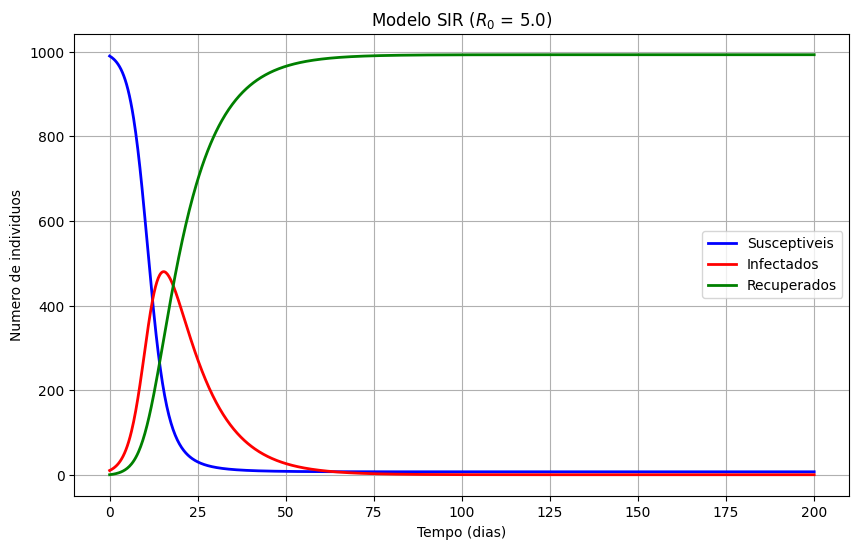

Pico de infeccao: 480 individuos
Tempo do pico: 15.4 dias
Ataque final: 99.3% da populacao


In [17]:
def sir_model(y, t, beta, gamma):
    """Modelo SIR"""
    S, I, R = y
    N = S + I + R
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Parametros
beta = 0.5   # taxa de transmissao (1/dia)
gamma = 0.1  # taxa de recuperacao (1/dia)
R0 = beta / gamma  # R0 = 5

# Condicoes iniciais
N_sir = 1000
I0_sir = 10
S0_sir = N_sir - I0_sir
R0_pop_sir = 0
y0_sir = [S0_sir, I0_sir, R0_pop_sir]

# Simular
t_sir = np.linspace(0, 200, 1000)
sol_sir = odeint(sir_model, y0_sir, t_sir, args=(beta, gamma))

S, I, R = sol_sir.T

# Plotar dinamica
plt.figure(figsize=(10, 6))
plt.plot(t_sir, S, 'b-', label='Susceptiveis', linewidth=2)
plt.plot(t_sir, I, 'r-', label='Infectados', linewidth=2)
plt.plot(t_sir, R, 'g-', label='Recuperados', linewidth=2)
plt.xlabel('Tempo (dias)')
plt.ylabel('Numero de individuos')
plt.title(f'Modelo SIR ($R_0$ = {R0:.1f})')
plt.legend()
plt.grid(True)
plt.show()

# Encontrar pico de infeccao
peak_idx = np.argmax(I)
peak_time = t_sir[peak_idx]
peak_infected = I[peak_idx]

print(f"Pico de infeccao: {peak_infected:.0f} individuos")
print(f"Tempo do pico: {peak_time:.1f} dias")
print(f"Ataque final: {R[-1]/N_sir*100:.1f}% da populacao")
